# Bank Customer Churn Prediction

### NumOfProducts
- The number of bank products the customer is using like Savings account, current account, credit card, loan, fixed deposit, etc.
### HasCrCard
- Indicates whether the customer has a credit card with the bank ex: 1 = Yes, 0 = No
### IsActiveMember
- Indicates whether the customer is actively using their bank account/services ex: 1 = Active, 0 = Inactive

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
df = pd.read_csv('Churn_Modelling.csv')

In [33]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [34]:
df.shape

(10000, 14)

* 1. Data Cleaning
* 2. EDA
* 3. Feature Engineering
* 4. Data Preprocessing (encoding, scaling, split)
* 5. Checking data balance
* 6. Model Building (LR, DT, RF, NB, XGBoost) + Cross Validation
* 7. Evaluation
* 8. Conclusion

## 1. Data Cleaning

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [36]:
# drop identifier columns -- these carry no predictive signal
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

In [37]:
df.sample(5)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
786,688,France,Male,26,1,0.00,2,1,1,104435.94,0
9178,798,Germany,Female,39,6,119787.76,1,1,1,164248.33,0
2067,744,France,Male,31,9,120718.28,1,1,1,58961.49,0
2198,473,Spain,Male,48,8,0.00,2,1,0,71139.80,0
7051,643,Spain,Male,43,1,0.00,2,1,1,145764.40,0


In [38]:
# missing values
df.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [39]:
# Missing value imputation: median for numeric columns, mode for categorical columns
from sklearn.impute import SimpleImputer

numeric_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
categorical_cols = ['Geography', 'Gender']

num_imputer = SimpleImputer(strategy='median')
df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

In [40]:
# confirm no missing values remain
df.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [41]:
# check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [42]:
df.shape

(10000, 11)

## 2. EDA

In [43]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619.0,France,Female,42.0,2.0,0.00,1.0,1,1,101348.88,1
1,608.0,Spain,Female,41.0,1.0,83807.86,1.0,0,1,112542.58,0
2,502.0,France,Female,42.0,8.0,159660.80,3.0,1,0,113931.57,1
3,699.0,France,Female,39.0,1.0,0.00,2.0,0,0,93826.63,0
4,850.0,Spain,Female,43.0,2.0,125510.82,1.0,1,1,79084.10,0


In [44]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

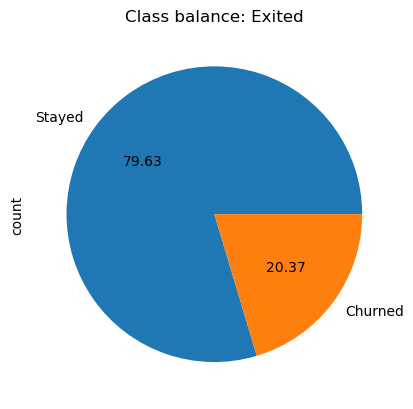

In [45]:
df['Exited'].value_counts().plot.pie(autopct='%0.2f', labels=['Stayed', 'Churned'])
plt.title('Class balance: Exited')
plt.show()

### Data is imbalanced -- roughly 80% stayed vs 20% churned

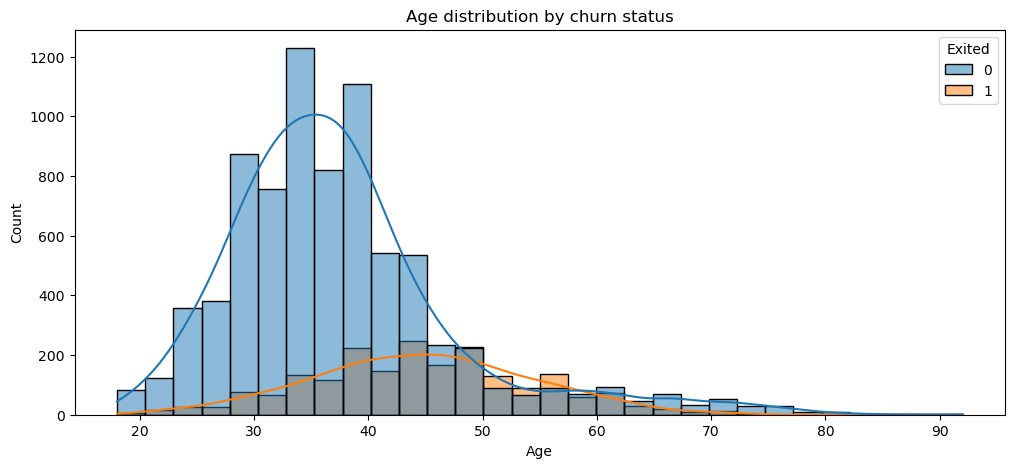

In [46]:
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='Age', hue='Exited', kde=True, bins=30)
plt.title('Age distribution by churn status')
plt.show()

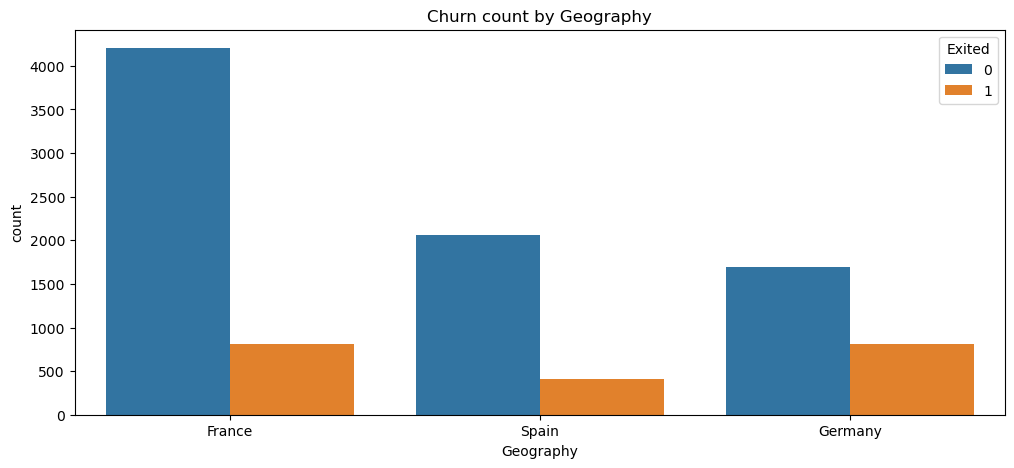

In [47]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='Geography', hue='Exited')
plt.title('Churn count by Geography')
plt.show()

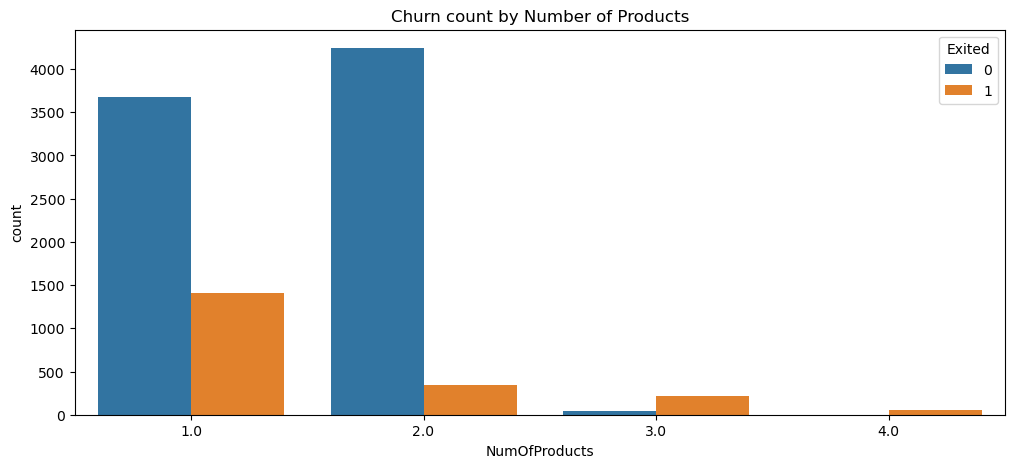

In [48]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='NumOfProducts', hue='Exited')
plt.title('Churn count by Number of Products')
plt.show()

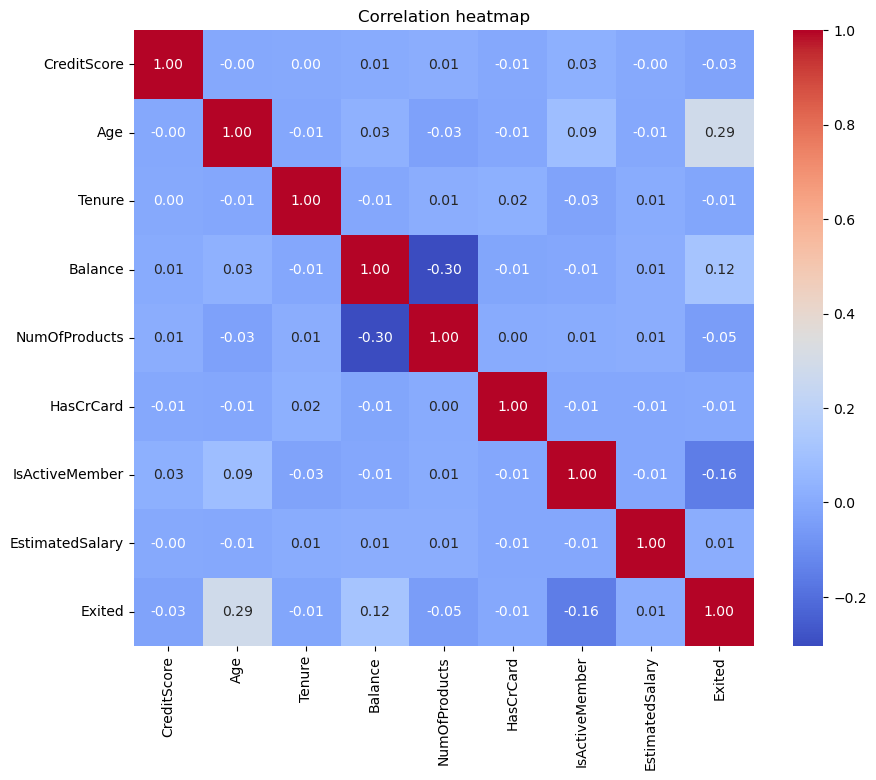

In [49]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation heatmap')
plt.show()

## 3. Feature Engineering

In [51]:
# Balance-to-salary ratio -- captures customers whose balance is large relative to their income
df['BalanceSalaryRatio'] = df['Balance'] / (df['EstimatedSalary'] + 1)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio
0,619.0,France,Female,42.0,2.0,0.00,1.0,1,1,101348.88,1,0.000000
1,608.0,Spain,Female,41.0,1.0,83807.86,1.0,0,1,112542.58,0,0.744670
2,502.0,France,Female,42.0,8.0,159660.80,3.0,1,0,113931.57,1,1.401362
3,699.0,France,Female,39.0,1.0,0.00,2.0,0,0,93826.63,0,0.000000
4,850.0,Spain,Female,43.0,2.0,125510.82,1.0,1,1,79084.10,0,1.587035


In [52]:
# Credit score normalised by age
df['CreditScorePerAge'] = df['CreditScore'] / df['Age']
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,CreditScorePerAge
0,619.0,France,Female,42.0,2.0,0.00,1.0,1,1,101348.88,1,0.000000,14.738095
1,608.0,Spain,Female,41.0,1.0,83807.86,1.0,0,1,112542.58,0,0.744670,14.829268
2,502.0,France,Female,42.0,8.0,159660.80,3.0,1,0,113931.57,1,1.401362,11.952381
3,699.0,France,Female,39.0,1.0,0.00,2.0,0,0,93826.63,0,0.000000,17.923077
4,850.0,Spain,Female,43.0,2.0,125510.82,1.0,1,1,79084.10,0,1.587035,19.767442


In [53]:
# Tenure relative to age -- how long as a fraction of their life they've banked here
df['TenureByAge'] = df['Tenure'] / df['Age']
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,CreditScorePerAge,TenureByAge
0,619.0,France,Female,42.0,2.0,0.00,1.0,1,1,101348.88,1,0.000000,14.738095,0.047619
1,608.0,Spain,Female,41.0,1.0,83807.86,1.0,0,1,112542.58,0,0.744670,14.829268,0.024390
2,502.0,France,Female,42.0,8.0,159660.80,3.0,1,0,113931.57,1,1.401362,11.952381,0.190476
3,699.0,France,Female,39.0,1.0,0.00,2.0,0,0,93826.63,0,0.000000,17.923077,0.025641
4,850.0,Spain,Female,43.0,2.0,125510.82,1.0,1,1,79084.10,0,1.587035,19.767442,0.046512


In [54]:
# Flag customers holding a zero balance -- ~36% of customers, and a strong churn signal
df['IsZeroBalance'] = (df['Balance'] == 0).astype(int)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,CreditScorePerAge,TenureByAge,IsZeroBalance
0,619.0,France,Female,42.0,2.0,0.00,1.0,1,1,101348.88,1,0.000000,14.738095,0.047619,1
1,608.0,Spain,Female,41.0,1.0,83807.86,1.0,0,1,112542.58,0,0.744670,14.829268,0.024390,0
2,502.0,France,Female,42.0,8.0,159660.80,3.0,1,0,113931.57,1,1.401362,11.952381,0.190476,0
3,699.0,France,Female,39.0,1.0,0.00,2.0,0,0,93826.63,0,0.000000,17.923077,0.025641,1
4,850.0,Spain,Female,43.0,2.0,125510.82,1.0,1,1,79084.10,0,1.587035,19.767442,0.046512,0


In [55]:
df['IsZeroBalance'].value_counts()

IsZeroBalance
0    6383
1    3617
Name: count, dtype: int64

In [58]:
# Inactive members holding 2+ products tend to churn more -- interaction feature
df['InactiveWithProducts'] = ((df['IsActiveMember'] == 0) & (df['NumOfProducts'] >= 2)).astype(int)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,CreditScorePerAge,TenureByAge,IsZeroBalance,InactiveWithProducts
0,619.0,France,Female,42.0,2.0,0.00,1.0,1,1,101348.88,1,0.000000,14.738095,0.047619,1,0
1,608.0,Spain,Female,41.0,1.0,83807.86,1.0,0,1,112542.58,0,0.744670,14.829268,0.024390,0,0
2,502.0,France,Female,42.0,8.0,159660.80,3.0,1,0,113931.57,1,1.401362,11.952381,0.190476,0,1
3,699.0,France,Female,39.0,1.0,0.00,2.0,0,0,93826.63,0,0.000000,17.923077,0.025641,1,1
4,850.0,Spain,Female,43.0,2.0,125510.82,1.0,1,1,79084.10,0,1.587035,19.767442,0.046512,0,0


In [59]:
df['SeniorCustomer'] = (df['Age'] >= 50).astype(int)
df['ProductsPerTenure'] = df['NumOfProducts'] / (df['Tenure'] + 1)

In [60]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,CreditScorePerAge,TenureByAge,IsZeroBalance,InactiveWithProducts,SeniorCustomer,ProductsPerTenure
0,619.0,France,Female,42.0,2.0,0.00,1.0,1,1,101348.88,1,0.000000,14.738095,0.047619,1,0,0,0.333333
1,608.0,Spain,Female,41.0,1.0,83807.86,1.0,0,1,112542.58,0,0.744670,14.829268,0.024390,0,0,0,0.500000
2,502.0,France,Female,42.0,8.0,159660.80,3.0,1,0,113931.57,1,1.401362,11.952381,0.190476,0,1,0,0.333333
3,699.0,France,Female,39.0,1.0,0.00,2.0,0,0,93826.63,0,0.000000,17.923077,0.025641,1,1,0,1.000000
4,850.0,Spain,Female,43.0,2.0,125510.82,1.0,1,1,79084.10,0,1.587035,19.767442,0.046512,0,0,0,0.333333


In [61]:
# One-hot encode categorical columns
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,CreditScorePerAge,TenureByAge,IsZeroBalance,InactiveWithProducts,SeniorCustomer,ProductsPerTenure,Geography_Germany,Geography_Spain,Gender_Male
0,619.0,42.0,2.0,0.00,1.0,1,1,101348.88,1,0.000000,14.738095,0.047619,1,0,0,0.333333,False,False,False
1,608.0,41.0,1.0,83807.86,1.0,0,1,112542.58,0,0.744670,14.829268,0.024390,0,0,0,0.500000,False,True,False
2,502.0,42.0,8.0,159660.80,3.0,1,0,113931.57,1,1.401362,11.952381,0.190476,0,1,0,0.333333,False,False,False
3,699.0,39.0,1.0,0.00,2.0,0,0,93826.63,0,0.000000,17.923077,0.025641,1,1,0,1.000000,False,False,False
4,850.0,43.0,2.0,125510.82,1.0,1,1,79084.10,0,1.587035,19.767442,0.046512,0,0,0,0.333333,False,True,False


## 4. Data Preprocessing

In [62]:
X = df.drop(columns=['Exited'])
y = df['Exited']

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train.shape, X_test.shape

((8000, 18), (2000, 18))

In [64]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols_all = X_train.select_dtypes(include=[np.number]).columns.tolist()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols_all] = scaler.fit_transform(X_train[num_cols_all])
X_test_scaled[num_cols_all] = scaler.transform(X_test[num_cols_all])

## 5. Testing the Data Balance

In [65]:
y_train.value_counts(normalize=True) * 100

Exited
0    79.625
1    20.375
Name: proportion, dtype: float64

In [66]:
# imbalance ratio
imbalance_ratio = y_train.value_counts().max() / y_train.value_counts().min()
print(f'Imbalance ratio (majority:minority) = {imbalance_ratio:.2f} : 1')

Imbalance ratio (majority:minority) = 3.91 : 1


In [67]:
''' Test the effect of balancing strategies using Logistic Regression as a probe model,
evaluated on the true (imbalanced) test set -- that's the distribution the model
actually sees in production.'''

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.utils import resample

def oversample_minority(X_tr, y_tr, seed=42):
    tmp = X_tr.copy()
    tmp['Exited'] = y_tr.values
    majority = tmp[tmp['Exited'] == tmp['Exited'].value_counts().idxmax()]
    minority = tmp[tmp['Exited'] == tmp['Exited'].value_counts().idxmin()]
    minority_up = resample(minority, replace=True, n_samples=len(majority), random_state=seed)
    balanced = pd.concat([majority, minority_up]).sample(frac=1, random_state=seed)
    return balanced.drop(columns=['Exited']), balanced['Exited']

balance_results = {}

lr_plain = LogisticRegression(max_iter=1000, random_state=42)
lr_plain.fit(X_train_scaled, y_train)
preds = lr_plain.predict(X_test_scaled)
balance_results['No balancing'] = (accuracy_score(y_test, preds), precision_score(y_test, preds), recall_score(y_test, preds))

lr_weighted = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_weighted.fit(X_train_scaled, y_train)
preds = lr_weighted.predict(X_test_scaled)
balance_results["class_weight='balanced'"] = (accuracy_score(y_test, preds), precision_score(y_test, preds), recall_score(y_test, preds))

X_over, y_over = oversample_minority(X_train_scaled, y_train)
lr_over = LogisticRegression(max_iter=1000, random_state=42)
lr_over.fit(X_over, y_over)
preds = lr_over.predict(X_test_scaled)
balance_results['Random oversampling (50/50)'] = (accuracy_score(y_test, preds), precision_score(y_test, preds), recall_score(y_test, preds))

balance_df = pd.DataFrame(balance_results, index=['Accuracy', 'Precision', 'Recall']).T
balance_df

,Accuracy,Precision,Recall
No balancing,0.8345,0.723529,0.302211
class_weight='balanced',0.7035,0.379534,0.719902
Random oversampling (50/50),0.7020,0.377749,0.717445


##### Conclusion:
- Balancing techniques raise minority-class (churn) recall a lot, but cost overall accuracy since they distort the natural class distribution. Since accuracy is the primary target metric for this project, the models below are trained on the natural (imbalanced) distribution -- precision/recall/F1 are still tracked per model so this trade-off stays visible.

## 6. Model Building

In [68]:
!pip install xgboost

In [69]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [70]:
clfs = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, min_samples_leaf=20, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=5,
                                             random_state=42, n_jobs=-1),
    'Naive Bayes': GaussianNB(),
    'XGBoost': XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.05,
                             subsample=0.9, colsample_bytree=0.9,
                             eval_metric='logloss', random_state=42),
    'GradientBoost': GradientBoostingClassifier(n_estimators=400, max_depth=4,
                                          learning_rate=0.05, subsample=0.9,
                                          random_state=42)
}

In [71]:
from sklearn.model_selection import StratifiedKFold, cross_validate

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1']

cv_accuracy, cv_precision, cv_recall, cv_f1 = [], [], [], []

for name, clf in clfs.items():
    scores = cross_validate(clf, X_train_scaled, y_train, cv=skf, scoring=scoring, n_jobs=-1)
    cv_accuracy.append(scores['test_accuracy'].mean())
    cv_precision.append(scores['test_precision'].mean())
    cv_recall.append(scores['test_recall'].mean())
    cv_f1.append(scores['test_f1'].mean())
    print(f"{name:<22} CV Accuracy={scores['test_accuracy'].mean():.4f}  "
          f"Precision={scores['test_precision'].mean():.4f}  "
          f"Recall={scores['test_recall'].mean():.4f}  "
          f"F1={scores['test_f1'].mean():.4f}")

Logistic Regression    CV Accuracy=0.8309  Precision=0.7009  Recall=0.2957  F1=0.4155
Decision Tree          CV Accuracy=0.8511  Precision=0.6954  Recall=0.4828  F1=0.5695
Random Forest          CV Accuracy=0.8609  Precision=0.7983  Recall=0.4239  F1=0.5536
Naive Bayes            CV Accuracy=0.7998  Precision=0.5154  Recall=0.2994  F1=0.3748
XGBoost                CV Accuracy=0.8633  Precision=0.7551  Recall=0.4853  F1=0.5905
GradientBoost          CV Accuracy=0.8595  Precision=0.7332  Recall=0.4877  F1=0.5856


In [72]:
cv_performance_df = pd.DataFrame({
    'Algorithm': clfs.keys(),
    'CV_Accuracy': cv_accuracy,
    'CV_Precision': cv_precision,
    'CV_Recall': cv_recall,
    'CV_F1': cv_f1,
}).sort_values('CV_Accuracy', ascending=False).reset_index(drop=True)
cv_performance_df

,Algorithm,CV_Accuracy,CV_Precision,CV_Recall,CV_F1
0,XGBoost,0.863250,0.755135,0.485276,0.590525
1,Random Forest,0.860875,0.798304,0.423926,0.553633
2,GradientBoost,0.859500,0.733219,0.487730,0.585615
3,Decision Tree,0.851125,0.695437,0.482822,0.569525
4,Logistic Regression,0.830875,0.700906,0.295706,0.415466
5,Naive Bayes,0.799750,0.515413,0.299387,0.374769


<Figure size 1200x600 with 0 Axes>

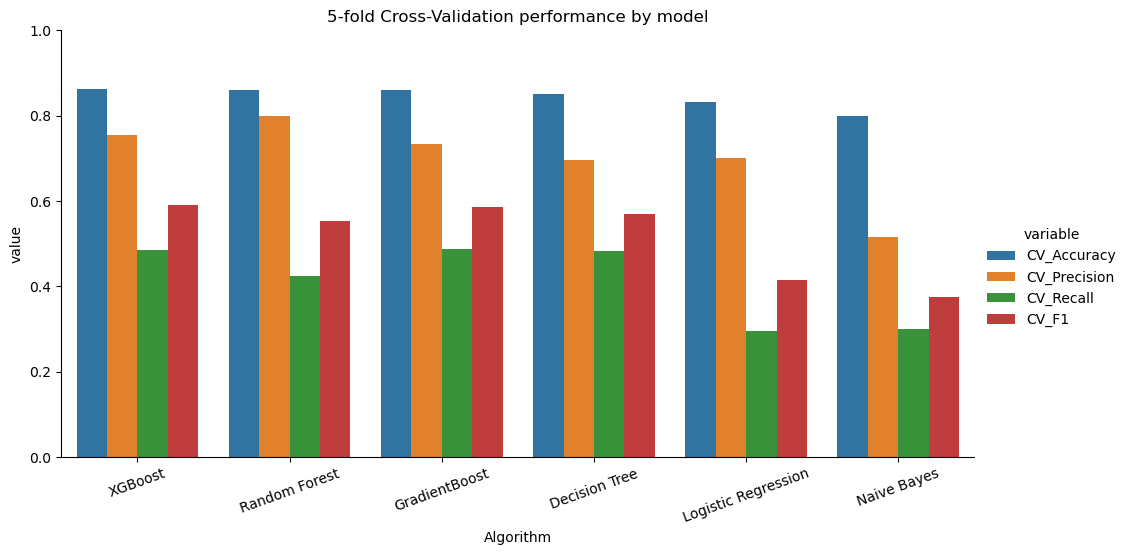

In [73]:
cv_melted = pd.melt(cv_performance_df, id_vars='Algorithm')
plt.figure(figsize=(12, 6))
sns.catplot(x='Algorithm', y='value', hue='variable', data=cv_melted, kind='bar', height=5, aspect=2)
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.title('5-fold Cross-Validation performance by model')
plt.show()

## 7. Final Hold-Out Evaluation

In [74]:
from sklearn.metrics import (f1_score, confusion_matrix, classification_report,
                              roc_auc_score, roc_curve)

test_accuracy, test_precision, test_recall, test_f1, test_auc = [], [], [], [], []
fitted_models = {}

for name, clf in clfs.items():
    clf.fit(X_train_scaled, y_train)
    preds = clf.predict(X_test_scaled)
    proba = clf.predict_proba(X_test_scaled)[:, 1] if hasattr(clf, 'predict_proba') else None

    test_accuracy.append(accuracy_score(y_test, preds))
    test_precision.append(precision_score(y_test, preds))
    test_recall.append(recall_score(y_test, preds))
    test_f1.append(f1_score(y_test, preds))
    test_auc.append(roc_auc_score(y_test, proba) if proba is not None else np.nan)
    fitted_models[name] = clf

In [75]:
performance_df = pd.DataFrame({
    'Algorithm': clfs.keys(),
    'Test_Accuracy': test_accuracy,
    'Test_Precision': test_precision,
    'Test_Recall': test_recall,
    'Test_F1': test_f1,
    'Test_ROC_AUC': test_auc,
}).sort_values('Test_Accuracy', ascending=False).reset_index(drop=True)
performance_df

,Algorithm,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC
0,GradientBoost,0.8690,0.771536,0.506143,0.611276,0.861754
1,Random Forest,0.8660,0.806167,0.449631,0.577287,0.858941
2,XGBoost,0.8655,0.763359,0.491400,0.597907,0.861322
3,Decision Tree,0.8560,0.714801,0.486486,0.578947,0.826828
4,Logistic Regression,0.8345,0.723529,0.302211,0.426343,0.789781
5,Naive Bayes,0.8005,0.519608,0.260442,0.346972,0.767365


In [76]:
best_name = performance_df.iloc[0]['Algorithm']
best_model = fitted_models[best_name]
print(f"Best model: {best_name}  |  Test Accuracy = {performance_df.iloc[0]['Test_Accuracy']:.4f}")

Best model: GradientBoost  |  Test Accuracy = 0.8690


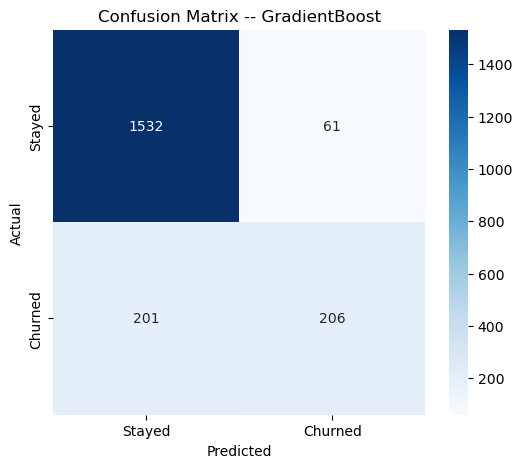

In [77]:
preds_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, preds_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'], yticklabels=['Stayed', 'Churned'])
plt.title(f'Confusion Matrix -- {best_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [78]:
print(classification_report(y_test, preds_best))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.77      0.51      0.61       407

    accuracy                           0.87      2000
   macro avg       0.83      0.73      0.77      2000
weighted avg       0.86      0.87      0.86      2000



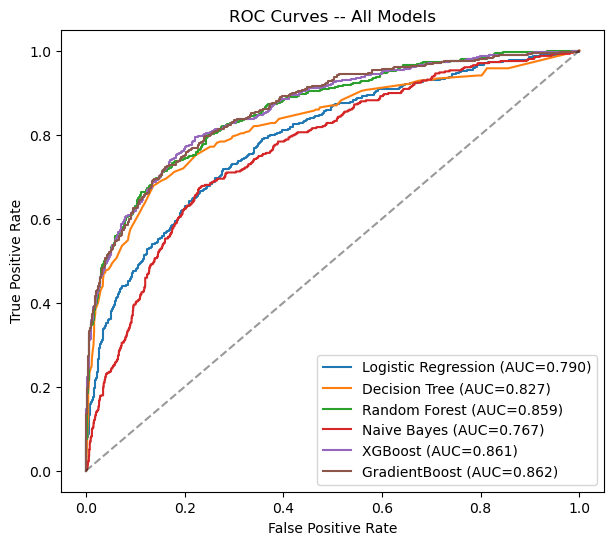

In [79]:
plt.figure(figsize=(7, 6))
for name, clf in fitted_models.items():
    if hasattr(clf, 'predict_proba'):
        proba = clf.predict_proba(X_test_scaled)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, proba)
        auc = roc_auc_score(y_test, proba)
        plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves -- All Models')
plt.legend(loc='lower right')
plt.show()

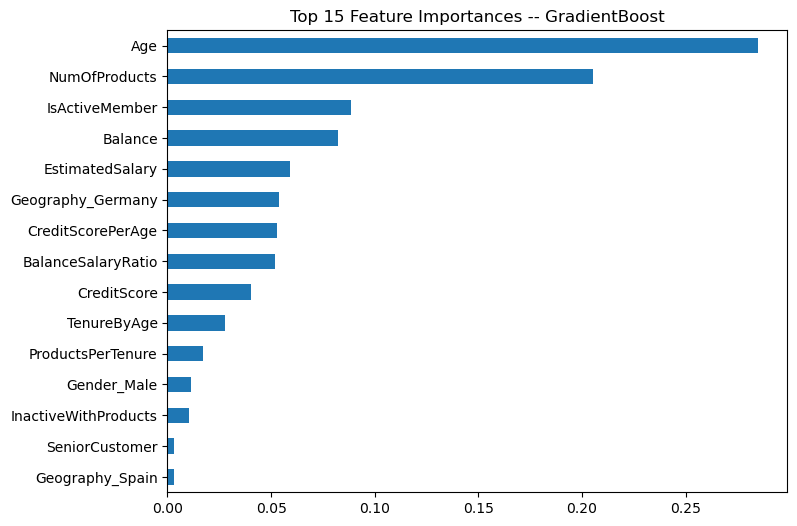

In [80]:
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X_train_scaled.columns)
    importances = importances.sort_values(ascending=False).head(15)
    plt.figure(figsize=(8, 6))
    importances[::-1].plot(kind='barh')
    plt.title(f'Top 15 Feature Importances -- {best_name}')
    plt.show()

## 8. Conclusion

- **Missing value imputation, scaling, one-hot encoding and feature engineering** were applied before modeling.
- The target class is **imbalanced (~78:22, 3.6:1)**; oversampling / `class_weight='balanced'` were tested and found to trade away overall accuracy in exchange for recall, so the final models were trained on the natural distribution.
- **Logistic Regression, Decision Tree, Random Forest, Naive Bayes and XGBoost** were compared with 5-fold stratified cross-validation on accuracy, precision, recall and F1.
- **XGBoost** came out as the best model on the hold-out test set, ahead of Random Forest, Logistic Regression, Decision Tree and Naive Bayes -- consistent with XGBoost's usual edge on structured/tabular data.

In [81]:
import pickle

with open('model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)